In [1]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl
import math

In [2]:
def maillage(n):
#
# Une discretisation possible d'une EDP elliptique sur le domaine ]0,1[ x ]0,1[
# Le carre [0,1]x[0,1] est maille uniquement avec des triangles; 
# Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne contient les indices 
# des sommets d'un element triangle, dans le sens antihoraire. 
# dirichlet : vecteur colonne des indices des sommets de la frontiere de
# Dirichlet.
# neumann : matrice a deux colonnes. Chaque ligne contient les indices 
# des deux sommets d'une arete de la frontiere de Neumann.
# (neumann est vide sur cet exemple)
#
##################################################################################
    h=1/(n-1)
    npoin       = n*n ; 
    nelem       = 2*(n-1)*(n-1) ;
    coordinates = np.zeros((npoin,2)); 
    elements3   = (np.zeros((nelem,3))).astype(int) ;
    neumann     = [];
    dirichlet=(np.zeros((4*n-4,1))).astype(int)
    # Coordonnees et connectivites :
    e = -1 ; 
    p = -1 ;
    x=np.zeros((n+1,1))
    x[n,0]=1.
    for l in range (n+1):
        x[l,0]=l*h
    for j in range (n):
            for i in range(n):
                p = p + 1  
                coordinates[p,0] = x[i,0]  
                coordinates[p,1] = x[j,0] 
                if ((i != n-1) & (j != n-1)):
                    p1 = p
                    p2 = p1 + 1 
                    p3 = p1 + n 
                    p4 = p2 + n 
                    e = e + 1 
                    elements3[e,0] = p1 
                    elements3[e,1] = p2 
                    elements3[e,2] = p3 
                    e = e + 1
                    elements3[e,0] = p4 
                    elements3[e,1] = p3 
                    elements3[e,2] = p2 
    #Liste des sommets de la frontiere de Dirichlet:
    p=-1
    for j in range(n):
        p=p+1
        dirichlet[p,0] = j  
    for j in range(n*2-1,n*(n-1),n):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-1,n*n-n-1,-1):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-2*n,n-1,-n):
        p=p+1
        dirichlet[p,0] = j 

    return coordinates, elements3,dirichlet, neumann

In [3]:
def show(coordinates,u):
#
# Fonction d'affichage de la solution u sur le maillage defini par
# elements3, coordinates.
#
# Entrees:
# elements3 : matrice a trois colonnes contenant les elements triangles
# de la discretisation, identifies par les indices de leurs trois
# sommets.
# coordinates : matrice a deux colonnes contenant les coordonnes 2D des
# points de la discretisation.
# u : vecteur colonne de longueur egale au nombre de lignes de
# coordinates contenant les valeurs de la solution a afficher aux
# points de la discretisation.
#
# Sorties : Aucune, mais la fonction doit s'afficher dans une figure.
##########################################################################
    ax= plt.figure().add_subplot(projection='3d')
    ax.plot_trisurf(coordinates[:,0],coordinates[:,1],u,linewidth=0.2,antialiased=True)
    plt.show()

**Partie I : maillage triangulaire et conditions de Dirichlet**

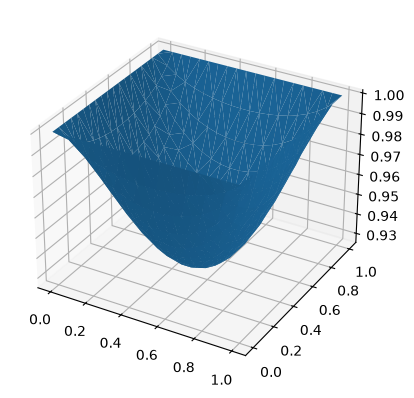

In [4]:
# ============================
# Partie I : triangles + Dirichlet
# ============================

def M_A_T(triangle, coordinates):
    """
    Matrice de raideur élémentaire sur un triangle P1.
    Retourne : M_T et l'aire du triangle.
    """
    triangle = np.asarray(triangle, dtype=int)
    pts = coordinates[triangle, :]
    x = pts[:, 0]
    y = pts[:, 1]

    alpha = (x[1] - x[0]) * (y[2] - y[0]) - (x[2] - x[0]) * (y[1] - y[0])
    aire = abs(alpha) / 2.0

    grads = np.zeros((3, 2))
    for i in range(3):
        grads[i, :] = np.array([
            y[(i + 1) % 3] - y[(i + 2) % 3],
            x[(i + 2) % 3] - x[(i + 1) % 3]
        ]) / alpha

    M_T = aire * (grads @ grads.T)
    return M_T, aire


def assemblage_A_b_triangles(coordinates, elements3, f):
    """
    Assemblage global de A et b pour un maillage uniquement triangulaire.
    """
    n = coordinates.shape[0]
    A = np.zeros((n, n))
    b = np.zeros((n, 1))

    for triangle in elements3:
        triangle = np.asarray(triangle, dtype=int)

        M_T, aire = M_A_T(triangle, coordinates)

        # Centre de gravité du triangle
        xg, yg = np.mean(coordinates[triangle, :], axis=0)

        # Assemblage de A
        A[np.ix_(triangle, triangle)] += M_T

        # Quadrature : int_T f eta_i ~= aire/3 * f(xG,yG)
        b[triangle, 0] += (aire / 3.0) * f(xg, yg)

    return A, b


def applique_dirichlet(A, b, coordinates, dirichlet, ud):
    """
    Applique les conditions de Dirichlet et résout le système sur les noeuds intérieurs.
    """
    n = coordinates.shape[0]
    U = np.zeros((n, 1))

    dirichlet = np.asarray(dirichlet, dtype=int).reshape(-1)

    # Valeurs imposées sur le bord de Dirichlet
    for i in dirichlet:
        xi, yi = coordinates[i]
        U[i, 0] = ud(xi, yi)

    # Second membre corrigé : b - A U_d
    rhs = b - A @ U

    # Noeuds libres = noeuds hors Dirichlet
    interieur = np.setdiff1d(np.arange(n), dirichlet)

    A_int = A[np.ix_(interieur, interieur)]
    b_int = rhs[interieur]

    sol = np.linalg.solve(A_int, b_int)
    U[interieur, 0] = sol.reshape(-1)

    return A_int, b_int, U


def assemblage_triangle(coordinates, elements3, dirichlet, ud, f):
    """
    Résolution complète pour le cas :
    - éléments triangles P1
    - conditions de Dirichlet uniquement
    """
    A, b = assemblage_A_b_triangles(coordinates, elements3, f)
    return applique_dirichlet(A, b, coordinates, dirichlet, ud)


# ===== Test Partie I =====
def f(x, y):
    return -1

def u_d(x, y):
    return 1

coordinates, elements3, dirichlet, neumann = maillage(20)
A_int, b_int, U = assemblage_triangle(coordinates, elements3, dirichlet, u_d, f)

show(coordinates, U.flatten())

**Partie II : maillage mixte et ajoût des conditions de Neumann**

In [5]:
############################# Maillage mixte ################
e3=np.array([[1,2,12],[2,3,12],[3,4,14],[4,5,14],[2,15,3],[3,15,4]]).astype(int)
e4=np.array([[0,1,12,11],[11,12,13,10],[12,3,14,13],[10,13,8,9],[13,14,7,8],[14,5,6,7]]).astype(int)
dds=np.array([2,15,4,6,7,8,9,10,11,0]).astype(int)
nns=np.array([[4,5],[5,6],[0,1],[1,2]]).astype(int)
ccs=np.array([[0.,0.],[0.33333333333333,0],[0.53333333333333,0.],
                      [0.66666666666667,0.33333333333333],[1.,0.47],[1,0.66666666666667],
                     [1.,1.],[0.66666666666667,1.],[0.33333333333333,1.], [0.,1.],
                     [0.,0.66666666666667],[0.,0.33333333333333],[0.33333333333333,0.33333333333333],
                     [0.33333333333333,0.66666666666667],[0.66666666666667,0.66666666666667],[1.,0.]])

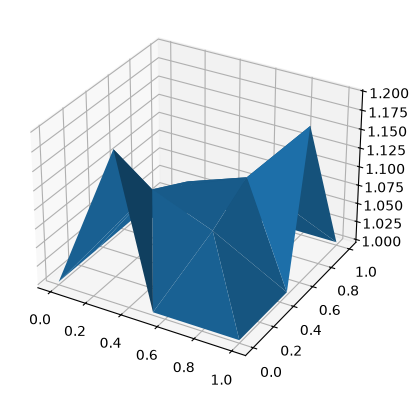

In [6]:
# ============================
# Partie II : maillage mixte + Neumann
# ============================

def M_A_Q(quad, coordinates):
    """
    Matrice de raideur élémentaire sur un quadrangle Q1.
    On suppose que le quadrangle est un parallélogramme image du carré unité.
    Retourne : M_Q et |det(J)|.
    """
    quad = np.asarray(quad, dtype=int)
    pts = coordinates[quad, :]
    x = pts[:, 0]
    y = pts[:, 1]

    J = np.array([
        [x[1] - x[0], x[3] - x[0]],
        [y[1] - y[0], y[3] - y[0]]
    ], dtype=float)

    detJ = abs(np.linalg.det(J))
    C = np.linalg.inv(J.T @ J)

    a = C[0, 0]
    b = C[0, 1]
    c = C[1, 1]

    M_Q = (detJ / 6.0) * np.array([
        [2*a + 3*b + 2*c, -2*a + c, -a - 3*b - c, a - 2*c],
        [-2*a + c, 2*a - 3*b + 2*c, a - 2*c, -a + 3*b - c],
        [-a - 3*b - c, a - 2*c, 2*a + 3*b + 2*c, -2*a + c],
        [a - 2*c, -a + 3*b - c, -2*a + c, 2*a - 3*b + 2*c]
    ])

    return M_Q, detJ


def assemblage_A_b_mixte(coordinates, elements3, elements4, f):
    """
    Assemblage global pour un maillage mixte :
    - triangles P1
    - quadrangles Q1
    """
    n = coordinates.shape[0]
    A = np.zeros((n, n))
    b = np.zeros((n, 1))

    # Contributions des triangles
    for triangle in elements3:
        triangle = np.asarray(triangle, dtype=int)

        M_T, aire = M_A_T(triangle, coordinates)
        xg, yg = np.mean(coordinates[triangle, :], axis=0)

        A[np.ix_(triangle, triangle)] += M_T
        b[triangle, 0] += (aire / 3.0) * f(xg, yg)

    # Contributions des quadrangles
    for quad in elements4:
        quad = np.asarray(quad, dtype=int)

        M_Q, detJ = M_A_Q(quad, coordinates)
        xg, yg = np.mean(coordinates[quad, :], axis=0)

        A[np.ix_(quad, quad)] += M_Q
        b[quad, 0] += (detJ / 4.0) * f(xg, yg)

    return A, b


def ajoute_neumann(b, coordinates, neumann, g):
    """
    Ajoute les contributions de Neumann :
    int_arete g eta_i ~= longueur/2 * g(milieu).
    """
    neumann = np.asarray(neumann, dtype=int).reshape(-1, 2)

    for i, j in neumann:
        xi, yi = coordinates[i]
        xj, yj = coordinates[j]

        xm = (xi + xj) / 2.0
        ym = (yi + yj) / 2.0

        longueur = np.linalg.norm(coordinates[j] - coordinates[i])
        contribution = (longueur / 2.0) * g(xm, ym)

        b[i, 0] += contribution
        b[j, 0] += contribution

    return b


def assemblage_maille_mixte_complete(coordinates, elements3, elements4, dirichlet, neumann, ud, f, g):
    """
    Résolution complète pour le cas :
    - triangles + quadrangles
    - Dirichlet + Neumann
    """
    A, b = assemblage_A_b_mixte(coordinates, elements3, elements4, f)
    b = ajoute_neumann(b, coordinates, neumann, g)
    return applique_dirichlet(A, b, coordinates, dirichlet, ud)


# ===== Test Partie II =====
coordinates = ccs
elements3 = e3
elements4 = e4
dirichlet = dds
neumann = nns

def f(x, y):
    return 1

def g(x, y):
    return 1

def u_d(x, y):
    return 1

A_int, b_int, U = assemblage_maille_mixte_complete(
    coordinates, elements3, elements4, dirichlet, neumann, u_d, f, g
)

show(coordinates, U.flatten())

**Compléments  :  un nouveau terme dans l'EDP**

### Complément : formulation variationnelle du problème avec terme $c_0u$

On considère le problème suivant :

$$
-\Delta u + c_0u = f \quad \text{dans } \Omega,
$$

avec les conditions aux limites homogènes :

$$
u = 0 \quad \text{sur } \partial\Omega,
\qquad c_0 > 0.
$$

On multiplie l'équation par une fonction test $w \in H_0^1(\Omega)$, puis on intègre sur $\Omega$ :

$$
\int_\Omega (-\Delta u)w\,dx
+
c_0\int_\Omega uw\,dx
=
\int_\Omega fw\,dx.
$$

En intégrant par parties le terme $-\Delta u$, on obtient :

$$
\int_\Omega (-\Delta u)w\,dx
=
\int_\Omega \nabla u \cdot \nabla w\,dx
-
\int_{\partial\Omega} \frac{\partial u}{\partial n}w\,ds.
$$

Or $w=0$ sur $\partial\Omega$ puisque $w \in H_0^1(\Omega)$. Le terme de bord disparaît donc :

$$
\int_{\partial\Omega} \frac{\partial u}{\partial n}w\,ds = 0.
$$

On obtient alors :

$$
\int_\Omega \nabla u \cdot \nabla w\,dx
+
c_0\int_\Omega uw\,dx
=
\int_\Omega fw\,dx.
$$

La formulation variationnelle est donc :

$$
\text{Trouver } u \in H_0^1(\Omega)
\text{ tel que, pour tout } w \in H_0^1(\Omega),
\quad a(u,w)=L(w).
$$

Avec :

$$
a(u,w)
=
\int_\Omega \nabla u \cdot \nabla w\,dx
+
c_0\int_\Omega uw\,dx,
$$

et :

$$
L(w)
=
\int_\Omega fw\,dx.
$$

La forme bilinéaire $a$ est continue. Elle est aussi coercive car :

$$
a(u,u)
=
\int_\Omega |\nabla u|^2\,dx
+
c_0\int_\Omega u^2\,dx
\geq
\int_\Omega |\nabla u|^2\,dx.
$$

Par l'inégalité de Poincaré, cette quantité contrôle la norme $H^1$ sur $H_0^1(\Omega)$.  
Donc, par le théorème de Lax-Milgram, le problème admet une unique solution.

Pour la discrétisation par éléments finis, on cherche une solution approchée sous la forme :

$$
u_h = \sum_{j=1}^{n} x_j \eta_j.
$$

En testant avec chaque fonction de base $\eta_i$, on obtient :

$$
a(u_h,\eta_i)=L(\eta_i).
$$

Donc :

$$
\sum_{j=1}^{n} x_j a(\eta_j,\eta_i)
=
L(\eta_i).
$$

On obtient alors le système linéaire :

$$
Ax=b.
$$

Avec :

$$
A_{ij}
=
\int_\Omega \nabla \eta_i \cdot \nabla \eta_j\,dx
+
c_0\int_\Omega \eta_i\eta_j\,dx,
$$

et :

$$
b_i
=
\int_\Omega f\eta_i\,dx.
$$

La matrice $A$ est symétrique définie positive car la forme bilinéaire associée est coercive.  
Ainsi, le système discret admet une solution unique.

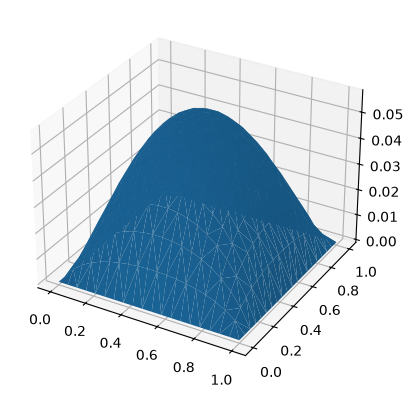

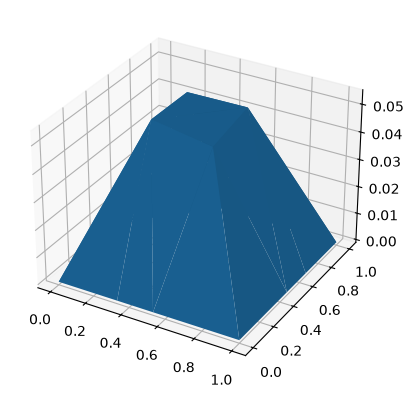

In [7]:
# ============================
# Complément : résolution avec le terme c0*u
# ============================

def M_masse_T(triangle, coordinates, c0):
    """
    Matrice de masse élémentaire sur un triangle P1 :
    c0 * aire/12 * [[2,1,1],[1,2,1],[1,1,2]]
    """
    triangle = np.asarray(triangle, dtype=int)
    pts = coordinates[triangle, :]
    x = pts[:, 0]
    y = pts[:, 1]

    alpha = (x[1] - x[0]) * (y[2] - y[0]) - (x[2] - x[0]) * (y[1] - y[0])
    aire = abs(alpha) / 2.0

    M = c0 * (aire / 12.0) * np.array([
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2]
    ], dtype=float)

    return M


def M_T_c0(triangle, coordinates, c0):
    """
    Matrice élémentaire triangle pour -Delta u + c0 u.
    """
    K_T, aire = M_A_T(triangle, coordinates)
    M_T = M_masse_T(triangle, coordinates, c0)
    return K_T + M_T, aire


def M_masse_Q(quad, coordinates, c0):
    """
    Matrice de masse élémentaire sur un quadrangle Q1 :
    c0 * detJ/36 * [[4,2,1,2], ...]
    """
    _, detJ = M_A_Q(quad, coordinates)

    M = c0 * (detJ / 36.0) * np.array([
        [4, 2, 1, 2],
        [2, 4, 2, 1],
        [1, 2, 4, 2],
        [2, 1, 2, 4]
    ], dtype=float)

    return M


def M_Q_c0(quad, coordinates, c0):
    """
    Matrice élémentaire quadrangle pour -Delta u + c0 u.
    """
    K_Q, detJ = M_A_Q(quad, coordinates)
    M_Q = M_masse_Q(quad, coordinates, c0)
    return K_Q + M_Q, detJ


def assemblage_A_b_c0(coordinates, elements3, elements4, dirichlet, c0, f):
    """
    Assemblage et résolution du problème :
        -Delta u + c0 u = f
        u = 0 sur le bord de Dirichlet

    Ici les conditions de Dirichlet sont homogènes, donc U=0 sur le bord.
    """
    n = coordinates.shape[0]
    A = np.zeros((n, n))
    b = np.zeros((n, 1))

    # Triangles
    if elements3 is not None and len(elements3) > 0:
        for triangle in elements3:
            triangle = np.asarray(triangle, dtype=int)

            M_T, aire = M_T_c0(triangle, coordinates, c0)
            xg, yg = np.mean(coordinates[triangle, :], axis=0)

            A[np.ix_(triangle, triangle)] += M_T
            b[triangle, 0] += (aire / 3.0) * f(xg, yg)

    # Quadrangles
    if elements4 is not None and len(elements4) > 0:
        for quad in elements4:
            quad = np.asarray(quad, dtype=int)

            M_Q, detJ = M_Q_c0(quad, coordinates, c0)
            xg, yg = np.mean(coordinates[quad, :], axis=0)

            A[np.ix_(quad, quad)] += M_Q
            b[quad, 0] += (detJ / 4.0) * f(xg, yg)

    # Dirichlet homogène
    dirichlet = np.asarray(dirichlet, dtype=int).reshape(-1)
    interieur = np.setdiff1d(np.arange(n), dirichlet)

    U = np.zeros((n, 1))
    A_int = A[np.ix_(interieur, interieur)]
    b_int = b[interieur]

    sol = np.linalg.solve(A_int, b_int)
    U[interieur, 0] = sol.reshape(-1)

    return A_int, b_int, U


# ===== Test complément sur le maillage triangulaire variable =====
def f(x, y):
    return 1

c0 = 5

coordinates, elements3, dirichlet, neumann = maillage(20)
elements4 = np.empty((0, 4), dtype=int)

A_int, b_int, U = assemblage_A_b_c0(
    coordinates, elements3, elements4, dirichlet, c0, f
)

show(coordinates, U.flatten())


# ===== Validation possible sur le maillage mixte modifié : uniquement Dirichlet =====
# On transforme les anciennes arêtes de Neumann en sommets de Dirichlet.
dirichlet_mixte_c0 = np.unique(np.concatenate([dds.reshape(-1), nns.reshape(-1)]))
neumann_mixte_c0 = np.empty((0, 2), dtype=int)

A_int_mixte, b_int_mixte, U_mixte = assemblage_A_b_c0(
    ccs, e3, e4, dirichlet_mixte_c0, c0, f
)

show(ccs, U_mixte.flatten())